## TASK 1

In [13]:
# Step 1
#--------------- GIVEN TO US BY THE INSTRUCTOR -----------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

  
# Read the CSV file.
data = pd.read_csv("CTG.csv", skiprows=1)

# Select the relevant numerical columns.
selected_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
                 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean',
                 'Median', 'Variance', 'Tendency', 'NSP']
data = data[selected_cols].dropna()

# Shuffle the dataset.
data_shuffled = data.sample(frac=1.0, random_state=1337)

# Split into input part X and output part Y.
X = data_shuffled.drop('NSP', axis=1)

# Map the diagnosis code to a human-readable label.
def to_label(y):
    return [None, 'normal', 'suspect', 'pathologic'][(int(y))]

Y = data_shuffled['NSP'].apply(to_label)

# Partition the data into training and test sets.
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=0)


#--------------- GIVEN TO US BY THE INSTRUCTOR -----------------

X.head()



,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency
1563,144.0,4.0,0.0,5.0,0.0,0.0,0.0,40.0,0.8,0.0,...,59.0,112.0,171.0,3.0,0.0,160.0,154.0,157.0,8.0,1.0
1241,115.0,6.0,0.0,7.0,1.0,0.0,0.0,23.0,1.5,0.0,...,57.0,94.0,151.0,2.0,0.0,120.0,121.0,122.0,6.0,0.0
21,128.0,3.0,272.0,2.0,2.0,0.0,1.0,26.0,1.7,0.0,...,141.0,57.0,198.0,9.0,0.0,129.0,125.0,132.0,34.0,0.0
98,148.0,0.0,1.0,0.0,1.0,0.0,0.0,61.0,0.5,39.0,...,31.0,130.0,161.0,2.0,0.0,154.0,152.0,154.0,1.0,1.0
39,115.0,9.0,54.0,5.0,0.0,0.0,0.0,27.0,2.3,0.0,...,129.0,53.0,182.0,7.0,0.0,119.0,120.0,120.0,14.0,0.0


In [14]:
# Step 2
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

clf = DummyClassifier(strategy='most_frequent')
#save score as a variable
score = cross_val_score(clf, Xtrain, Ytrain)

# aggrigate function = avg
avg = np.mean(score)
print(avg)

0.7794117647058824


In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import Perceptron
import numpy as np

# Random Forest Tuning

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=1337),
                       rf_params,
                       cv=5,
                       n_jobs=-1)

rf_grid.fit(Xtrain, Ytrain)
best_rf = rf_grid.best_estimator_

rf_score = cross_val_score(best_rf, Xtrain, Ytrain)

# Perceptron Tuning

perceptron_params = {
    'penalty': [None, 'l2', 'l1'],
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [1000, 2000]
}

perceptron_grid = GridSearchCV(Perceptron(random_state=1337),
                               perceptron_params,
                               cv=5,
                               n_jobs=-1)

perceptron_grid.fit(Xtrain, Ytrain)
best_perceptron = perceptron_grid.best_estimator_

perceptron_score = cross_val_score(best_perceptron, Xtrain, Ytrain)

# Gradient Boosting Tuning

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=1337),
                       gb_params,
                       cv=5,
                       n_jobs=-1)

gb_grid.fit(Xtrain, Ytrain)
best_gb = gb_grid.best_estimator_

gradientboosting_score = cross_val_score(best_gb, Xtrain, Ytrain)


# Results

print("Random Forest Best Params:", rf_grid.best_params_)
print("Random Forest Score:", np.mean(rf_score))

print("Perceptron Best Params:", perceptron_grid.best_params_)
print("Perceptron Score:", np.mean(perceptron_score))

print("Gradient Boosting Best Params:", gb_grid.best_params_)
print("Gradient Boosting Score:", np.mean(gradientboosting_score))

Random Forest Classifier Score: 0.9388235294117647
Perceptron Classifier Score: 0.7805882352941176
Gradient Boosting Classifier Score: 0.95


In [16]:
# Step 4
from sklearn.metrics import accuracy_score
# Dummy Classifier
clf.fit(Xtrain, Ytrain)
Yguess = clf.predict(Xtest)
print("Dummy Classifier Accuracy:", accuracy_score(Ytest, Yguess))
# Random Forest Classifier
randomforestclf.fit(Xtrain, Ytrain)
Yguess_rf = randomforestclf.predict(Xtest)
print("Random Forest Classifier Accuracy:", accuracy_score(Ytest, Yguess_rf))
# Perceptron Classifier
perceptronclf.fit(Xtrain, Ytrain)
Yguess_perceptron = perceptronclf.predict(Xtest)
print("Perceptron Classifier Accuracy:", accuracy_score(Ytest, Yguess_perceptron))
# Gradient Boosting Classifier
gradientboostingclf.fit(Xtrain, Ytrain)
Yguess_gradientboosting = gradientboostingclf.predict(Xtest)
print("Gradient Boosting Classifier Accuracy:", accuracy_score(Ytest, Yguess_gradientboosting))



Dummy Classifier Accuracy: 0.7746478873239436
Random Forest Classifier Accuracy: 0.9483568075117371
Perceptron Classifier Accuracy: 0.823943661971831
Gradient Boosting Classifier Accuracy: 0.9530516431924883


### REPORT TASK 1
We evaluated three different classifiers:
-> The Random Forest classifier achieved an accuracy of 0.9484.
-> Perceptron classifier achieved 0.8239.
-> Gradient Boosting classifier achieved the highest accuracy of 0.9531.

In Step 4, we selected the Gradient Boosting classifier because it provided the best performance among the tested models. This classifier builds an ensemble of weak learners in a sequential manner, where each new model focuses on correcting the errors made by the previous ones. The final selected model achieved an accuracy of 0.9531.

## TASK 2

Depth: 1, Score: 0.8276470588235295
Depth: 2, Score: 0.8864705882352941
Depth: 3, Score: 0.9
Depth: 4, Score: 0.9188235294117648
Depth: 5, Score: 0.9205882352941176
Depth: 6, Score: 0.9194117647058823
Depth: 7, Score: 0.9241176470588235
Depth: 8, Score: 0.9170588235294117
Depth: 9, Score: 0.9217647058823528
Depth: 10, Score: 0.9217647058823528
Best Depth: 7, Best Score: 0.9241176470588235


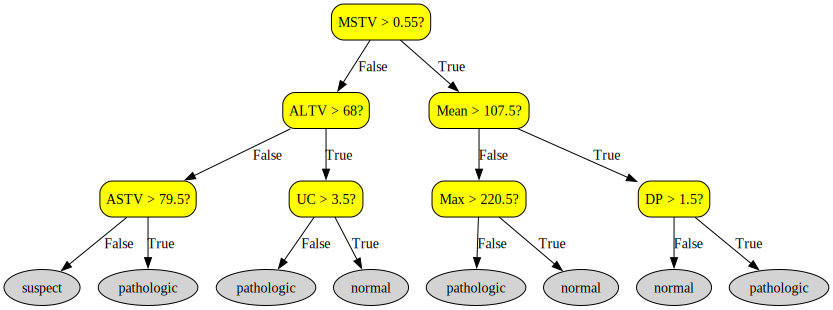

In [17]:
# TASK 2 code
# ---------- GIVEN TO US BY THE INSTRUCTOR -----------------
import numpy as np
import pandas as pd
from sklearn.base import ClassifierMixin
from sklearn.model_selection import cross_val_score
from collections import Counter
from graphviz import Digraph
from sklearn.base import BaseEstimator, ClassifierMixin
from abc import ABC, abstractmethod

def majority_sum_scorer(n_low, low_distr, n_high, high_distr):
    maj_sum_low = low_distr.most_common(1)[0][1]
    maj_sum_high = high_distr.most_common(1)[0][1]
    return maj_sum_low + maj_sum_high
    
def entropy(distr):
    n = sum(distr.values())
    ps = [n_i/n for n_i in distr.values()]
    return -sum(p*np.log2(p) if p > 0 else 0 for p in ps)

def info_gain_scorer(n_low, low_distr, n_high, high_distr):
    return -(n_low*entropy(low_distr)+n_high*entropy(high_distr))/(n_low+n_high)

def gini_impurity(distr):
    n = sum(distr.values())
    ps = [n_i/n for n_i in distr.values()]
    return 1-sum(p**2 for p in ps)
    
def gini_scorer(n_low, low_distr, n_high, high_distr):
    return -(n_low*gini_impurity(low_distr)+n_high*gini_impurity(high_distr))/(n_low+n_high)


 # Utility function to draw a tree visually using graphviz.
class DecisionTreeLeaf:

    def __init__(self, value):
        self.value = value

    # This method computes the prediction for this leaf node. This will just return a constant value.
    def predict(self, x):
        return self.value

    # Utility function to draw a tree visually using graphviz.
    def draw_tree(self, graph, node_counter, names):
        node_id = str(node_counter)
        val_str = f'{self.value:.4g}' if isinstance(self.value, float) else str(self.value)
        graph.node(node_id, val_str, style='filled')
        return node_counter+1, node_id
        
    def __eq__(self, other):
        if isinstance(other, DecisionTreeLeaf):
            return self.value == other.value
        else:
            return False
    
from graphviz import Digraph
from sklearn.base import BaseEstimator, ClassifierMixin
from abc import ABC, abstractmethod

class DecisionTree(ABC, BaseEstimator):

    def __init__(self, max_depth):
        super().__init__()
        self.max_depth = max_depth
        
    # As usual in scikit-learn, the training method is called *fit*. We first process the dataset so that
    # we're sure that it's represented as a NumPy matrix. Then we call the recursive tree-building method
    # called make_tree (see below).
    def fit(self, X, Y):
        if isinstance(X, pd.DataFrame):
            self.names = X.columns
            X = X.to_numpy()
        elif isinstance(X, list):
            self.names = None
            X = np.array(X)
        else:
            self.names = None
        Y = np.array(Y)        
        self.root = self.make_tree(X, Y, self.max_depth)
        
    def draw_tree(self):
        graph = Digraph()
        self.root.draw_tree(graph, 0, self.names)
        return graph
    
    # By scikit-learn convention, the method *predict* computes the classification or regression output
    # for a set of instances.
    # To implement it, we call a separate method that carries out the prediction for one instance.
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()
        return [self.predict_one(x) for x in X]

    # Predicting the output for one instance.
    def predict_one(self, x):
        return self.root.predict(x)        

    # This is the recursive training 
    def make_tree(self, X, Y, max_depth):

        # We start by computing the default value that will be used if we'll return a leaf node.
        # For classifiers, this will be the most common value in Y.
        default_value = self.get_default_value(Y)

        # First the two base cases in the recursion: is the training set completely
        # homogeneous, or have we reached the maximum depth? Then we need to return a leaf.

        # If we have reached the maximum depth, return a leaf with the majority value.
        if max_depth == 0:
            return DecisionTreeLeaf(default_value)

        # If all the instances in the remaining training set have the same output value,
        # return a leaf with this value.
        if self.is_homogeneous(Y):
            return DecisionTreeLeaf(default_value)

        # Select the "most useful" feature and split threshold. To rank the "usefulness" of features,
        # we use one of the classification or regression criteria.
        # For each feature, we call best_split (defined in a subclass). We then maximize over the features.
        n_features = X.shape[1]
        _, best_feature, best_threshold = max(self.best_split(X, Y, feature) for feature in range(n_features))
        
        if best_feature is None:
            return DecisionTreeLeaf(default_value)

        # Split the training set into subgroups, based on whether the selected feature is greater than
        # the threshold or not
        X_low, X_high, Y_low, Y_high = self.split_by_feature(X, Y, best_feature, best_threshold)

        # Build the subtrees using a recursive call. Each subtree is associated
        # with a value of the feature.
        low_subtree = self.make_tree(X_low, Y_low, max_depth-1)
        high_subtree = self.make_tree(X_high, Y_high, max_depth-1)

        if low_subtree == high_subtree:
            return low_subtree

        # Return a decision tree branch containing the result.
        return DecisionTreeBranch(best_feature, best_threshold, low_subtree, high_subtree)
    
    # Utility method that splits the data into the "upper" and "lower" part, based on a feature
    # and a threshold.
    def split_by_feature(self, X, Y, feature, threshold):
        low = X[:,feature] <= threshold
        high = ~low
        return X[low], X[high], Y[low], Y[high]
    
    # The following three methods need to be implemented by the classification and regression subclasses.
    
    @abstractmethod
    def get_default_value(self, Y):
        pass

    @abstractmethod
    def is_homogeneous(self, Y):
        pass

    @abstractmethod
    def best_split(self, X, Y, feature):
        pass

class DecisionTreeBranch:

    def __init__(self, feature, threshold, low_subtree, high_subtree):
        self.feature = feature
        self.threshold = threshold
        self.low_subtree = low_subtree
        self.high_subtree = high_subtree

    # For a branch node, we compute the prediction by first considering the feature, and then 
    # calling the upper or lower subtree, depending on whether the feature is or isn't greater
    # than the threshold.
    def predict(self, x):
        if x[self.feature] <= self.threshold:
            return self.low_subtree.predict(x)
        else:
            return self.high_subtree.predict(x)

    # Utility function to draw a tree visually using graphviz.
    def draw_tree(self, graph, node_counter, names):
        node_counter, low_id = self.low_subtree.draw_tree(graph, node_counter, names)
        node_counter, high_id = self.high_subtree.draw_tree(graph, node_counter, names)
        node_id = str(node_counter)
        fname = f'F{self.feature}' if names is None else names[self.feature]
        lbl = f'{fname} > {self.threshold:.4g}?'
        graph.node(node_id, lbl, shape='box', fillcolor='yellow', style='filled, rounded')
        graph.edge(node_id, low_id, 'False')
        graph.edge(node_id, high_id, 'True')
        return node_counter+1, node_id


class TreeClassifier(DecisionTree, ClassifierMixin):

    def __init__(self, max_depth=10, criterion='maj_sum'):
        super().__init__(max_depth)
        self.criterion = criterion
        
    def fit(self, X, Y):
        # For decision tree classifiers, there are some different ways to measure
        # the homogeneity of subsets.
        if self.criterion == 'maj_sum':
            self.criterion_function = majority_sum_scorer
        elif self.criterion == 'info_gain':
            self.criterion_function = info_gain_scorer
        elif self.criterion == 'gini':
            self.criterion_function = gini_scorer
        else:
            raise Exception(f'Unknown criterion: {self.criterion}')
        super().fit(X, Y)
        self.classes_ = sorted(set(Y))

    # Select a default value that is going to be used if we decide to make a leaf.
    # We will select the most common value.
    def get_default_value(self, Y):
        self.class_distribution = Counter(Y)
        return self.class_distribution.most_common(1)[0][0]
    
    # Checks whether a set of output values is homogeneous. In the classification case, 
    # this means that all output values are identical.
    # We assume that we called get_default_value just before, so that we can access
    # the class_distribution attribute. If the class distribution contains just one item,
    # this means that the set is homogeneous.
    def is_homogeneous(self, Y):
        return len(self.class_distribution) == 1
        
    # Finds the best splitting point for a given feature. We'll keep frequency tables (Counters)
    # for the upper and lower parts, and then compute the impurity criterion using these tables.
    # In the end, we return a triple consisting of
    # - the best score we found, according to the criterion we're using
    # - the id of the feature
    # - the threshold for the best split
    def best_split(self, X, Y, feature):

        # Create a list of input-output pairs, where we have sorted
        # in ascending order by the input feature we're considering.
        sorted_indices = np.argsort(X[:, feature])        
        X_sorted = list(X[sorted_indices, feature])
        Y_sorted = list(Y[sorted_indices])

        n = len(Y)

        # The frequency tables corresponding to the parts *before and including*
        # and *after* the current element.
        low_distr = Counter()
        high_distr = Counter(Y)

        # Keep track of the best result we've seen so far.
        max_score = -np.inf
        max_i = None

        # Go through all the positions (excluding the last position).
        for i in range(0, n-1):

            # Input and output at the current position.
            x_i = X_sorted[i]
            y_i = Y_sorted[i]
            
            # Update the frequency tables.
            low_distr[y_i] += 1
            high_distr[y_i] -= 1

            # If the input is equal to the input at the next position, we will
            # not consider a split here.
            #x_next = XY[i+1][0]
            x_next = X_sorted[i+1]
            if x_i == x_next:
                continue

            # Compute the homogeneity criterion for a split at this position.
            score = self.criterion_function(i+1, low_distr, n-i-1, high_distr)

            # If this is the best split, remember it.
            if score > max_score:
                max_score = score
                max_i = i

        # If we didn't find any split (meaning that all inputs are identical), return
        # a dummy value.
        if max_i is None:
            return -np.inf, None, None

        # Otherwise, return the best split we found and its score.
        split_point = 0.5*(X_sorted[max_i] + X_sorted[max_i+1])
        return max_score, feature, split_point


# -------- GIVEN TO US BY THE INSTRUCTOR -----------------

# find best max depth for tree classifier
best_score = -np.inf
best_depth = None
for depth in range(1, 11):
    treeclf = TreeClassifier(max_depth=depth, criterion='gini')
    score = cross_val_score(treeclf, Xtrain, Ytrain)
    avg_score = np.mean(score)
    print(f"Depth: {depth}, Score: {avg_score}")
    if avg_score > best_score:
        best_score = avg_score
        best_depth = depth
print(f"Best Depth: {best_depth}, Best Score: {best_score}")

cls = TreeClassifier(max_depth=3, criterion='gini')
cls.fit(Xtrain, Ytrain)
cls.draw_tree()



## Task 2 Report
Testing values 1 - 10: we got that best depth was 7!
Score for depth 7: 0.9241176470588235

### TASK 3

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Read the Excel file using Pandas.
alldata = pd.read_excel('Hemnet_data.xlsx')

# # Convert the timestamp string to an integer representing the year.
alldata['year'] = pd.DatetimeIndex(alldata['Sold Date']).year

# Convert 'yes' to 1 and 'no' to 0
alldata['Balcony'] = alldata['Balcony'].map({'Yes': 1, 'No': 0})
alldata['Patio'] = alldata['Patio'].map({'Yes': 1, 'No': 0})
alldata['Lift'] = alldata['Lift'].map({'Yes': 1, 'No': 0})

# Select the 12 input columns and the output column.
selected_columns = ['Final Price (kr)', 'year',  'Num of Room', 'Living Area (m²)', 'Balcony', 'Patio','Current Floor', 'Total Floor', 'Lift', 'Built Year', 'Fee (kr/month)', 'Operating Fee (kr/year)']
alldata = alldata[selected_columns]
alldata = alldata.dropna()

# Shuffle.
alldata_shuffled = alldata.sample(frac=1.0, random_state=0)

# Separate the input and output columns.
X = alldata_shuffled.drop('Final Price (kr)', axis=1)
# For the output, we'll use the log of the sales price.
Y = alldata_shuffled['Final Price (kr)'].apply(np.log)

#----------------------------------------------------

# I added this in order to Remove 'kr' and convert to numeric because it does not work otherwise (data cleaning)
X = X.replace({'kr': ''}, regex=True)

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

#-----------------------------------------------------

# Split into training and test sets.
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=0)

In [19]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate

dummyreg = DummyRegressor()
dummyreg_scores = cross_validate(dummyreg, Xtrain, Ytrain, scoring='neg_mean_squared_error')
dummyreg_mse = -dummyreg_scores['test_score']

print("MSE scores per fold:", dummyreg_mse)
print("Mean MSE score: ", dummyreg_mse.mean())

MSE scores per fold: [0.35548711 0.35827597 0.31759722 0.34236524 0.35596055]
Mean MSE score:  0.34593721954567236


In [20]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
# TUNING HYPERPARAMETERS FOR GRADIENT BOOSTING REGRESSOR
# DONE WITH GRID SEARCH CROSS-VALIDATION
gbreg = GradientBoostingRegressor(random_state=0)

param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [ 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3, 5],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=gbreg,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(Xtrain, Ytrain)

print("Best parameters:", grid_search.best_params_)
print("Best MSE:", -grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}
Best MSE: 0.1493185542485606


In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
# TUNING HYPERPARAMETERS FOR RANDOM FOREST REGRESSOR
# DONE WITH RANDOMIZED SEARCH CROSS-VALIDATION

rf = RandomForestRegressor(random_state=1337)

param_dist = {
    'n_estimators': np.arange(100, 500, 50),
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': np.arange(2, 15),
    'min_samples_leaf': np.arange(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=1337,
    n_jobs=-1,
    verbose=1
)

random_search.fit(Xtrain, Ytrain)

print("Best parameters:", random_search.best_params_)
print("Best MSE:", -random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'n_estimators': np.int64(100), 'min_samples_split': np.int64(5), 'min_samples_leaf': np.int64(1), 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}
Best MSE: 0.14672808270488474


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# for feature scaling and MLPRegressor
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=0, max_iter=1000))])

# TUNING HYPERPARAMETERS FOR MLP REGRESSOR
# DONE WITH RANDOMIZED SEARCH CROSS-VALIDATION

param_dist = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (100,50), (100,100), (200,)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': np.logspace(-5, -1, 10),  # regularization
    'mlp__learning_rate_init': np.logspace(-4, -2, 10),
    'mlp__solver': ['adam'],  # keep adam for stability
    'mlp__batch_size': ['auto', 32, 64, 128]
}

random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=0,
    n_jobs=-1,
    verbose=1
)

random_search.fit(Xtrain, Ytrain)

print("Best parameters:", random_search.best_params_)
print("Best MSE:", -random_search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters: {'mlp__solver': 'adam', 'mlp__learning_rate_init': np.float64(0.001291549665014884), 'mlp__hidden_layer_sizes': (100, 50), 'mlp__batch_size': 'auto', 'mlp__alpha': np.float64(0.0005994842503189409), 'mlp__activation': 'tanh'}
Best MSE: 0.16272716466041984


In [25]:
rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': np.arange(50, 101),  # fixed range
    'max_depth': [None, 10, 20],
    'min_samples_split': np.arange(2, 10),
    'min_samples_leaf': np.arange(1, 5),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(Xtrain, Ytrain)

print("Best params:", random_search.best_params_)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'n_estimators': np.int64(69), 'min_samples_split': np.int64(4), 'min_samples_leaf': np.int64(1), 'max_features': None, 'max_depth': None, 'bootstrap': True}


### NOTES TASK 3
The regression models that I have used are: Linear Regression, Gradient Boosting Regressor, Random Forest Regressor and MLPRegressor.

After tuning the hyperparameters using cross-validation, the models achieved the following performance (measured using mean squared error, MSE):

Gradient Boosting Regressor: 0.1493
Random Forest Regressor: 0.1467
MLPRegressor: 0.1627

Among these, the Random Forest Regressor achieved the best performance with a mean MSE score of 0.1467, making it the most accurate model on the validation data.

(note: my computer ins really old and some of the tuning had to be reduced since some the tuning took uppwards of 30 minutes and I didnt have that amount of time...) // nils

### TASK 4